# FIP 13 — DA and NE regressed on the task and on movement

How much of DA and NE does a task model explain, how much does movement (ME) add, and what is
left of the DA–NE correlation once the task and movement are removed?

1. Variance explained by the task model, by lagged ME, and by both
2. The model in one session
3. Fitted kernels
4. The DA–NE correlation with task and movement removed
5. The DA–NE correlation by timescale, raw and with the task removed
6. Numbers

`fip_14` refits the regression with other task models (events only, events + RPE) and a longer ME span.

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals, not
timing in the brain.

**Movement** is motion energy (ME) from the bottom camera: the summed absolute frame-to-frame pixel
change, from the aligned ME table (`fip_motion_energy_aligned`, frame times corrected by the video
timing QC). Cameras that fail the video timing or quality screen are left out (`men_01`).

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets. Each animal
contributes one hemisphere (the side with more sessions), with DA and NE from that side; animals
need at least 3 sessions (`fu.inventory_pairs`, `fu.choose_side`, `fu.load_pairs`). Traces sit on
one 20 Hz grid from 5 s before the first go cue to 10 s after the last; ME is averaged into the same
bins (`fu.add_motion_energy`). Each trace is z-scored over the session.

**Statistics.** Session values are averaged within animal; tests are Wilcoxon signed-rank on animal
means (smallest two-sided p with 9 animals: 0.004). Error bands are SEM over animals.

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data ─────────────────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded

# ── Models ───────────────────────────────────────────────────────────────────
KERNEL_S = (-1.0, 4.0)     # task-event kernels: go cue, rewarded / unrewarded outcome, lick
ME_LAGS_S = (-1.0, 2.0)    # ME regressors: the signal may follow ME by up to 2 s, or lead it by 1 s
N_SHIFT_R2 = 10            # circular shifts of ME for the variance-explained null
MIN_SHIFT_S = 60.0         # smallest circular shift

# ── 5. Timescales ────────────────────────────────────────────────────────────
BANDS = [(1 / 600, 1 / 120), (1 / 120, 1 / 30), (1 / 30, 1 / 8), (1 / 8, 0.5), (0.5, 2.0)]
BAND_NAMES = ["2–10 min", "30 s–2 min", "8–30 s", "2–8 s", "0.5–2 s"]
N_NULL = 200               # circular shifts per session for the band null
MIN_SHIFT_BAND_S = 120.0   # smallest circular shift for the band null
MAXLAG_S = 3.0             # residual cross-correlation

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne", "me")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"], "me": "0.25"}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)", "me": "ME (bottom camera)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.55"}
NULL_COLOR = PALETTE["not_sig"]
EVENTS = ["go cue", "rewarded outcome", "unrewarded outcome", "lick"]     # fu.event_design order
EVENT_COLOR = {"go cue": OKABE_ITO["sky_blue"], "rewarded outcome": OKABE_ITO["orange"],
               "unrewarded outcome": "0.55", "lick": OKABE_ITO["bluish_green"],
               "ME": OKABE_ITO["reddish_purple"]}
rng = np.random.default_rng(0)

## 0. Data

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
all_pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
pairs = fu.add_motion_energy(all_pairs, kept, CAMERA, ME_DATA_ROOT, onset_fs=None,
                             exclude_subjects=EXCLUDE_SUBJECTS)

SUBJECTS = sorted({p["subject"] for p in pairs})
PAIR_SUBJECTS = [p["subject"] for p in pairs]
N_ANIMALS = len(SUBJECTS)
print(f"{len(pairs)} of {len(all_pairs)} sessions have bottom-camera ME; {N_ANIMALS} animals")
pd.Series(PAIR_SUBJECTS).value_counts().sort_index().rename("sessions").to_frame().T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


88 of 97 sessions have bottom-camera ME; 9 animals


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,4,15,8,19,3,5,5,7,22


In [4]:
def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()


KERNEL_T = np.arange(int(round(KERNEL_S[0] * FS)), int(round(KERNEL_S[1] * FS))) / FS
ME_T = np.arange(int(round(ME_LAGS_S[0] * FS)), int(round(ME_LAGS_S[1] * FS)) + 1) / FS
N_K = len(KERNEL_T)


def split_beta(beta):
    # {event: kernel, 'intercept': b0, 'ME': filter} from a task(+ME) coefficient vector
    k = {e: beta[i * N_K:(i + 1) * N_K] for i, e in enumerate(EVENTS)}
    k["intercept"] = beta[4 * N_K]
    if len(beta) > 4 * N_K + 1:
        k["ME"] = beta[4 * N_K + 1:]
    return k

## 1. Variance explained

Variance of DA and NE explained (R², in sample) by the task model (`fu.task_residuals`: FIR kernels
−1 to 4 s for go cue, rewarded and unrewarded outcome, every lick), by lagged ME alone (−1 to +2 s),
and by the task model plus lagged ME. The ME increment is set against the same fit with ME
circularly shifted (≥ 60 s, 10 shifts), which removes its alignment and keeps its autocorrelation,
so the null absorbs what extra regressors add by chance.

In [5]:
r2_rows, resid, model_fits = [], {}, []
for p in pairs:
    z = p["z"]
    me_cols = fu.lagged_columns(z["me"], FS, ME_LAGS_S)
    task = fu.task_residuals(p, KERNEL_S)
    me_only = fu.task_residuals(p, KERNEL_S, extra=me_cols, task=False)
    both = fu.task_residuals(p, KERNEL_S, extra=me_cols)
    null = {"da": [], "ne": []}
    n = len(z["me"])
    for shift in rng.integers(int(MIN_SHIFT_S * FS), n - int(MIN_SHIFT_S * FS), N_SHIFT_R2):
        f = fu.task_residuals(p, KERNEL_S, extra=fu.lagged_columns(np.roll(z["me"], shift), FS, ME_LAGS_S))
        for s in ("da", "ne"):
            null[s].append(f[f"{s}_r2"] - task[f"{s}_r2"])
    r = dict(subject=p["subject"], session=p["session"])
    for s in ("da", "ne"):
        r.update({f"{s}_task": task[f"{s}_r2"], f"{s}_me": me_only[f"{s}_r2"],
                  f"{s}_task_me": both[f"{s}_r2"],
                  f"{s}_me_added": both[f"{s}_r2"] - task[f"{s}_r2"],
                  f"{s}_me_added_null": np.median(null[s])})
        r[f"{s}_me_added_vs_null"] = r[f"{s}_me_added"] - r[f"{s}_me_added_null"]
    r2_rows.append(r)
    resid[p["session"]] = dict(task=task, me_only=me_only, both=both)
    model_fits.append(dict(subject=p["subject"], session=p["session"],
                           **{f"{s}_{m}_{q}": f[f"{s}_{q}"] for s in ("da", "ne")
                              for m, f in (("task", task), ("both", both)) for q in ("beta", "r2")}))

r2_sess = pd.DataFrame(r2_rows)
r2_animal = st.animal_means(r2_sess, [c for c in r2_sess if c not in ("subject", "session")],
                            by_session=False)
report("variance explained (R²)", r2_animal, list(r2_animal))

── variance explained (R²)
            measure     mean      sem       p  n
            da_task    0.453   0.0224 0.00391  9
              da_me    0.162   0.0194 0.00391  9
         da_task_me    0.472   0.0209 0.00391  9
        da_me_added   0.0189  0.00629 0.00391  9
   da_me_added_null   0.0005 4.45e-05 0.00391  9
da_me_added_vs_null   0.0184  0.00628 0.00391  9
            ne_task    0.254   0.0297 0.00391  9
              ne_me    0.491   0.0386 0.00391  9
         ne_task_me    0.535   0.0375 0.00391  9
        ne_me_added    0.281   0.0335 0.00391  9
   ne_me_added_null 0.000646 6.54e-05 0.00391  9
ne_me_added_vs_null     0.28   0.0336 0.00391  9



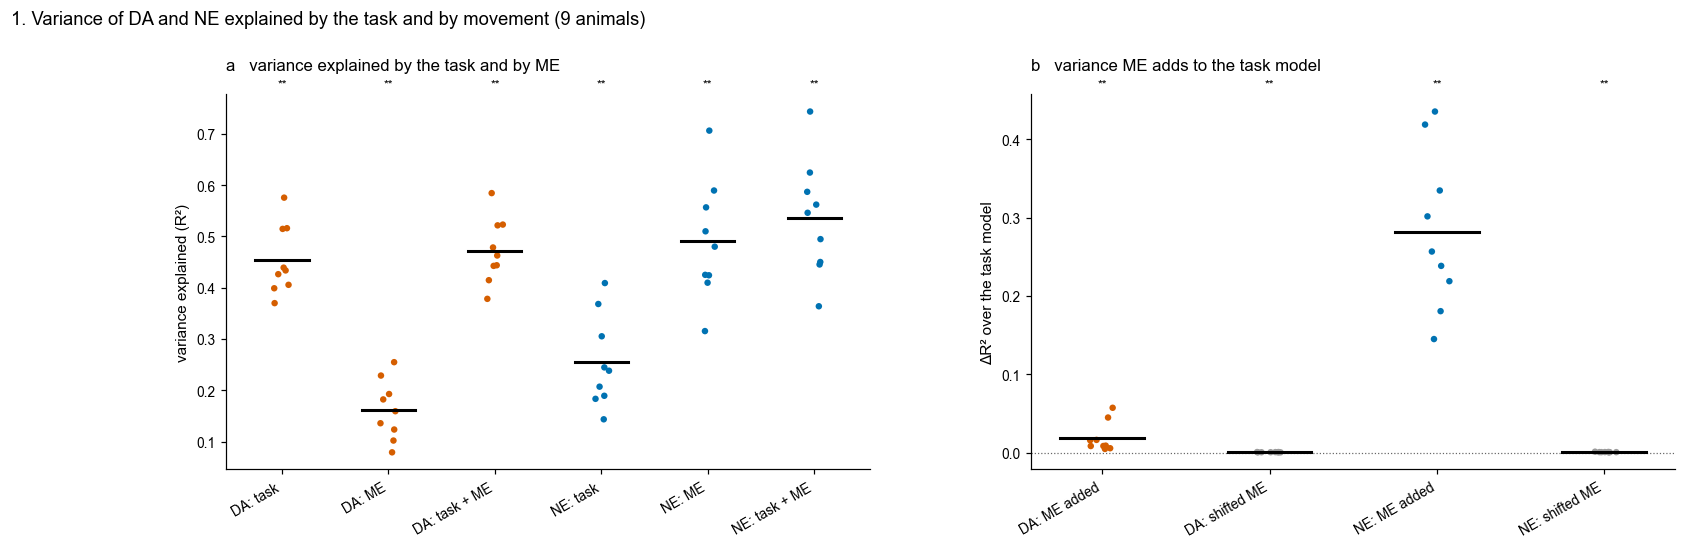

── ME added beyond the task, minus shifted-ME null
            measure   mean     sem       p  n
da_me_added_vs_null 0.0184 0.00628 0.00391  9
ne_me_added_vs_null   0.28  0.0336 0.00391  9



In [6]:
fig = plt.figure(figsize=(17, 4.8))
gs = GridSpec(1, 2, figure=fig, wspace=0.25, top=0.82)
ax = fig.add_subplot(gs[0])
cols = ["da_task", "da_me", "da_task_me", "ne_task", "ne_me", "ne_task_me"]
pu.strip_by_measure(ax, r2_animal, cols,
                    ["DA: task", "DA: ME", "DA: task + ME", "NE: task", "NE: ME", "NE: task + ME"],
                    [SIG_COLOR["da"]] * 3 + [SIG_COLOR["ne"]] * 3, "variance explained (R²)",
                    title="a   variance explained by the task and by ME", zero=False, connect=False)
ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, r2_animal, ["da_me_added", "da_me_added_null", "ne_me_added", "ne_me_added_null"],
                    ["DA: ME added", "DA: shifted ME", "NE: ME added", "NE: shifted ME"],
                    [SIG_COLOR["da"], NULL_COLOR, SIG_COLOR["ne"], NULL_COLOR], "ΔR² over the task model",
                    title="b   variance ME adds to the task model", connect=False)
fig.suptitle(f"1. Variance of DA and NE explained by the task and by movement ({N_ANIMALS} animals)",
             x=0.01, ha="left")
save_fig(fig, "fip_13_1_variance", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
report("ME added beyond the task, minus shifted-ME null", r2_animal,
       ["da_me_added_vs_null", "ne_me_added_vs_null"])

## 2. The model in one session

The task model and the task + ME model of section 1, drawn for one session (the one whose NE ΔR² from
ME is closest to the median). Each sample of the signal is predicted as

$$\hat y(t) = b_0 + \sum_{e}\sum_{\ell = -1\,\mathrm{s}}^{+3.95\,\mathrm{s}} k_e(\ell)\,[\text{event } e \text{ at } t - \ell] + \sum_{L = -1\,\mathrm{s}}^{+2\,\mathrm{s}} w(L)\, \mathrm{ME}(t - L)$$

for event types *e* = go cue, rewarded outcome, unrewarded outcome, lick. One least-squares fit per
session and signal finds the kernels $k_e$ and the ME filter $w$ that minimize the squared error over
every sample of the session.

- **a** inputs: event times and ME.
- **b, d** NE and DA with the task-model and task + ME predictions.
- **c** the task + ME prediction of NE split into what each event type and ME contribute.
- **e** the design matrix *X* over 6 s of panel a: one row per sample, one column per event type ×
  lag (1 where that event happened that long before the sample) and per ME lag (the ME value then).
  The prediction is $X\beta$.

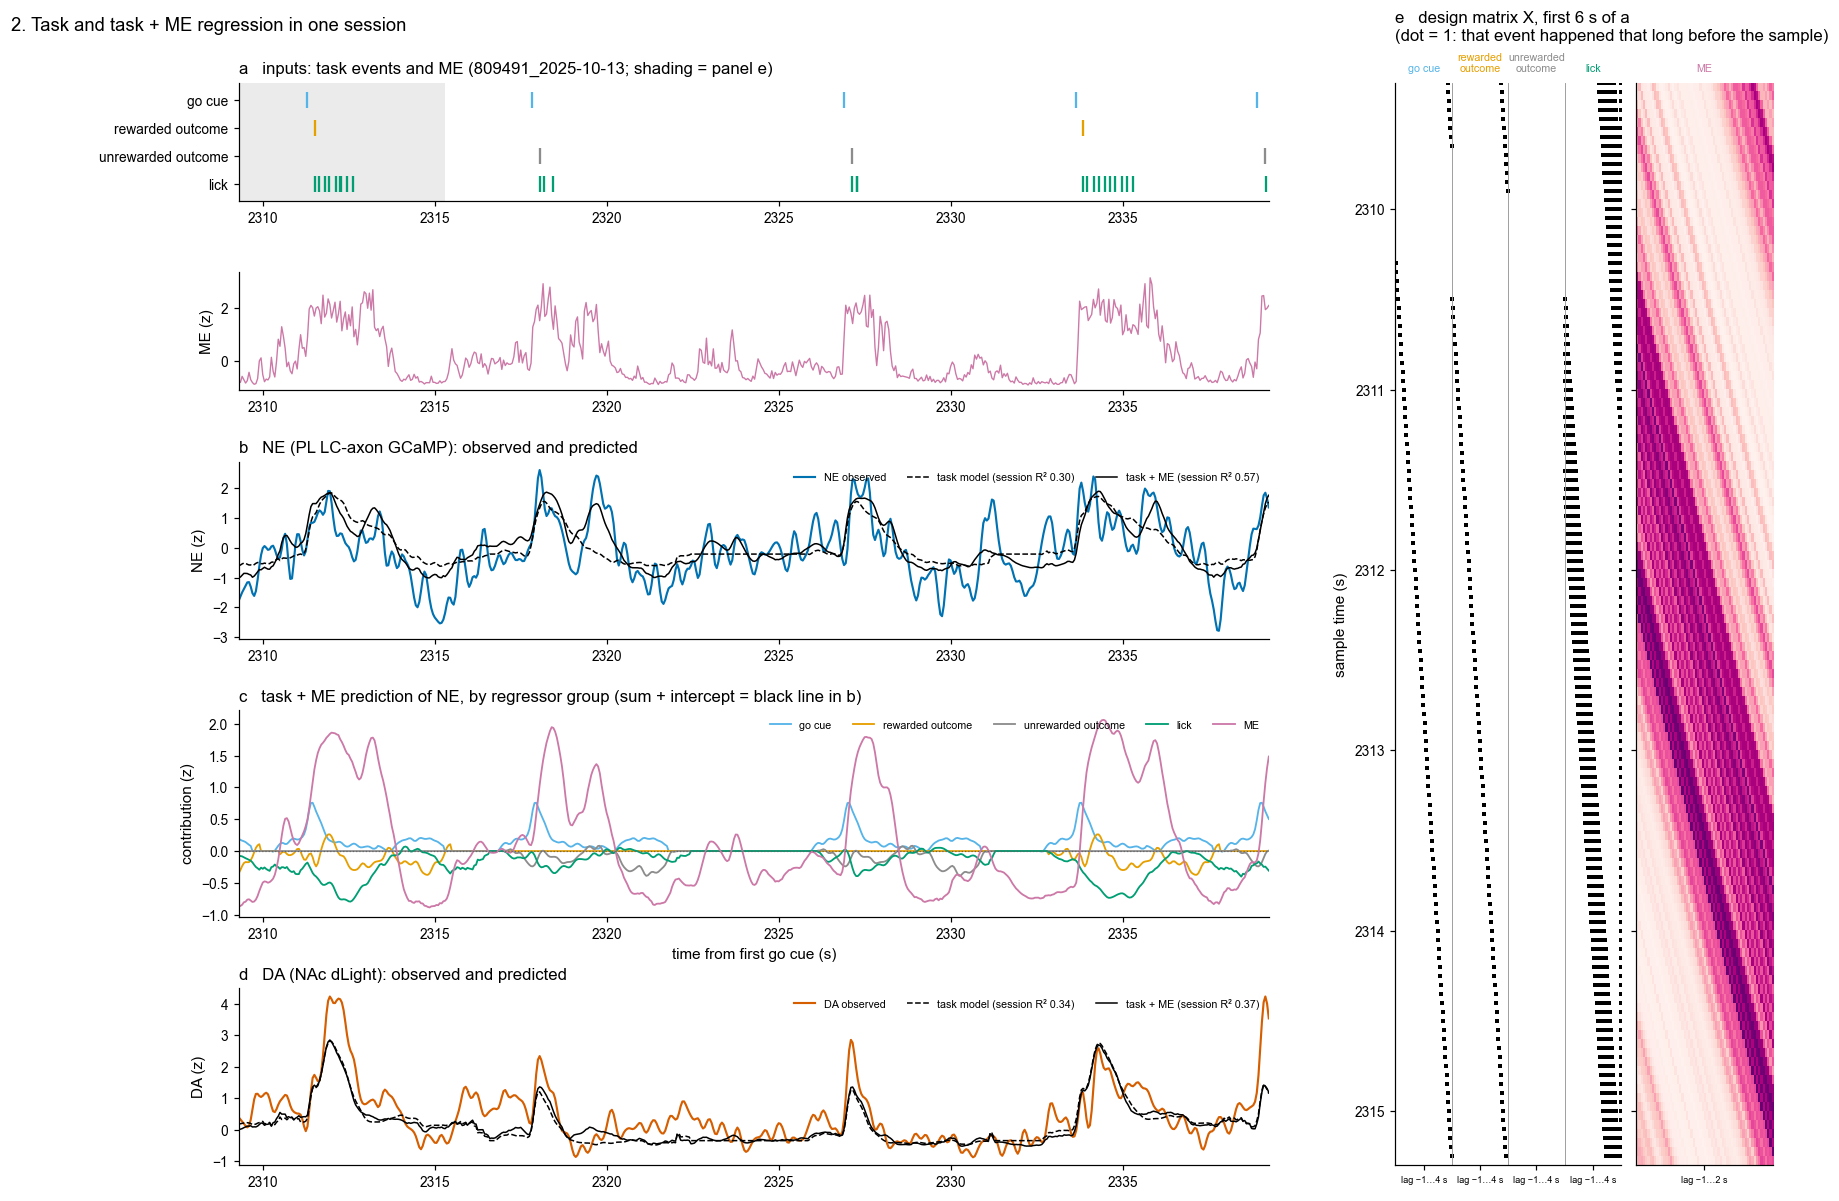

In [7]:
WIN_S, X_WIN_S = 30.0, 6.0
d_r2 = np.array([m["ne_both_r2"] - m["ne_task_r2"] for m in model_fits])
ex_i = int(np.argmin(np.abs(d_r2 - np.median(d_r2))))
ex, exf = pairs[ex_i], model_fits[ex_i]
t = ex["t0"] + np.arange(len(ex["da"])) / FS
tr = ex["trials"]
cues = tr["goCue_start_time_in_session"].dropna().to_numpy()
start = cues[cues >= np.median(cues)][0] - 2.0
win = (t >= start) & (t < start + WIN_S)
i0, i1 = np.flatnonzero(win)[[0, -1]]

X_task = fu.event_design(ex, KERNEL_S)[i0:i1 + 1].toarray()
X_me = fu.lagged_columns(ex["z"]["me"], FS, ME_LAGS_S)[i0:i1 + 1]
tw = t[i0:i1 + 1]


def parts(sig, model):
    # each event type's and ME's contribution to the prediction in the window
    k = split_beta(exf[f"{sig}_{model}_beta"])
    out = {e: X_task[:, i * N_K:(i + 1) * N_K] @ k[e] for i, e in enumerate(EVENTS)}
    if "ME" in k:
        out["ME"] = X_me @ k["ME"]
    return out, k["intercept"]


fig = plt.figure(figsize=(18, 12))
gs = GridSpec(5, 2, figure=fig, width_ratios=[3, 1.1], height_ratios=[0.8, 0.8, 1.2, 1.4, 1.2],
              hspace=0.45, wspace=0.18, top=0.93)

# a: inputs
ax = fig.add_subplot(gs[0, 0])
responded = tr["animal_response"] < 2
rew = tr["earned_reward"].fillna(0).astype(bool) & responded
outc = tr["reward_outcome_time_in_session"]
rows = [("go cue", cues), ("rewarded outcome", outc[rew].dropna().to_numpy()),
        ("unrewarded outcome", outc[responded & ~rew].dropna().to_numpy()), ("lick", ex["licks"])]
for y, (name, times) in enumerate(rows):
    times = times[(times >= tw[0]) & (times <= tw[-1])]
    ax.plot(times, np.full(len(times), -y), "|", color=EVENT_COLOR[name], ms=10, mew=1.5)
ax.set_yticks(-np.arange(len(rows)))
ax.set_yticklabels([r[0] for r in rows])
ax.set_ylim(-len(rows) + 0.4, 0.6)
ax.set_xlim(tw[0], tw[-1])
ax.axvspan(tw[0], tw[0] + X_WIN_S, color="0.92", lw=0, zorder=0)
ax.set_title(f"a   inputs: task events and ME ({ex['session']}; shading = panel e)", loc="left")
style_ax(ax)
ax = fig.add_subplot(gs[1, 0], sharex=ax)
ax.plot(tw, ex["z"]["me"][i0:i1 + 1], color=EVENT_COLOR["ME"], lw=0.9)
ax.set_ylabel("ME (z)")
style_ax(ax)

# b, d: observed and predicted
for row, sig, letter in ((2, "ne", "b"), (4, "da", "d")):
    ax = fig.add_subplot(gs[row, 0], sharex=ax)
    ax.plot(tw, ex["z"][sig][i0:i1 + 1], color=SIG_COLOR[sig], lw=1.4, label=f"{sig.upper()} observed")
    for model, ls, lab in (("task", "--", "task model"), ("both", "-", "task + ME")):
        pr, b0 = parts(sig, model)
        ax.plot(tw, b0 + sum(pr.values()), color="k", ls=ls, lw=1.0,
                label=f"{lab} (session R² {exf[f'{sig}_{model}_r2']:.2f})")
    ax.set_ylabel(f"{sig.upper()} (z)")
    ax.legend(fontsize=7, ncol=3, loc="upper right")
    ax.set_title(f"{letter}   {SIG_LABEL[sig]}: observed and predicted", loc="left")
    style_ax(ax)

# c: NE prediction split by regressor group
ax = fig.add_subplot(gs[3, 0], sharex=ax)
pr, b0 = parts("ne", "both")
for name, y in pr.items():
    ax.plot(tw, y, color=EVENT_COLOR[name], lw=1.2, label=name)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_ylabel("contribution (z)")
ax.legend(fontsize=7, ncol=5, loc="upper right")
ax.set_title("c   task + ME prediction of NE, by regressor group (sum + intercept = black line in b)",
             loc="left")
style_ax(ax)
ax.set_xlabel("time from first go cue (s)")

# e: design matrix
sub = gs[:, 1].subgridspec(1, 2, width_ratios=[4 * N_K, 4 * len(ME_T)], wspace=0.08)
n_rows = int(X_WIN_S * FS)
ax = fig.add_subplot(sub[0])
rr, cc = np.nonzero(X_task[:n_rows])         # the 1s, drawn as dots so single columns stay visible
ax.scatter(cc + 0.5, tw[0] + rr / FS, s=7, color="k", marker="s", lw=0)
ax.set_xlim(0, 4 * N_K)
ax.set_ylim(tw[0] + X_WIN_S, tw[0])
for i, e in enumerate(EVENTS):
    ax.axvline(i * N_K, color="0.6", lw=0.6)
    ax.text((i + 0.5) * N_K, tw[0] - 0.05, e.replace(" outcome", "\noutcome"), ha="center",
            va="bottom", fontsize=7, color=EVENT_COLOR[e])
ax.set_xticks([(i + 0.5) * N_K for i in range(4)])
ax.set_xticklabels(["lag −1…4 s"] * 4, fontsize=6)
ax.set_ylabel("sample time (s)")
ax.set_title("e   design matrix X, first 6 s of a\n(dot = 1: that event happened that long before the sample)", loc="left", pad=28)
ax2 = fig.add_subplot(sub[1], sharey=ax)
ax2.imshow(X_me[:n_rows], aspect="auto", cmap="RdPu", interpolation="nearest",
           extent=[0, len(ME_T), tw[0] + X_WIN_S, tw[0]], vmin=-1, vmax=3)
ax2.text(len(ME_T) / 2, tw[0] - 0.05, "ME", ha="center", va="bottom", fontsize=7,
         color=EVENT_COLOR["ME"])
ax2.set_xticks([len(ME_T) / 2])
ax2.set_xticklabels(["lag −1…2 s"], fontsize=6)
plt.setp(ax2.get_yticklabels(), visible=False)
fig.suptitle("2. Task and task + ME regression in one session", x=0.01, ha="left")
save_fig(fig, "fip_13_2_model", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. Fitted kernels

The kernels of section 1's models, session kernels averaged within animal (mean ± SEM over animals).
Solid: task model; dashed: task + ME. Each event kernel is that event's response on top of every other
regressor: the outcome kernels sit on top of the go-cue and lick kernels of the same trial, and the
lick kernel is the response per single lick. The ME filter is the response per 1 z of ME at each lag
(+ lag: signal after ME).

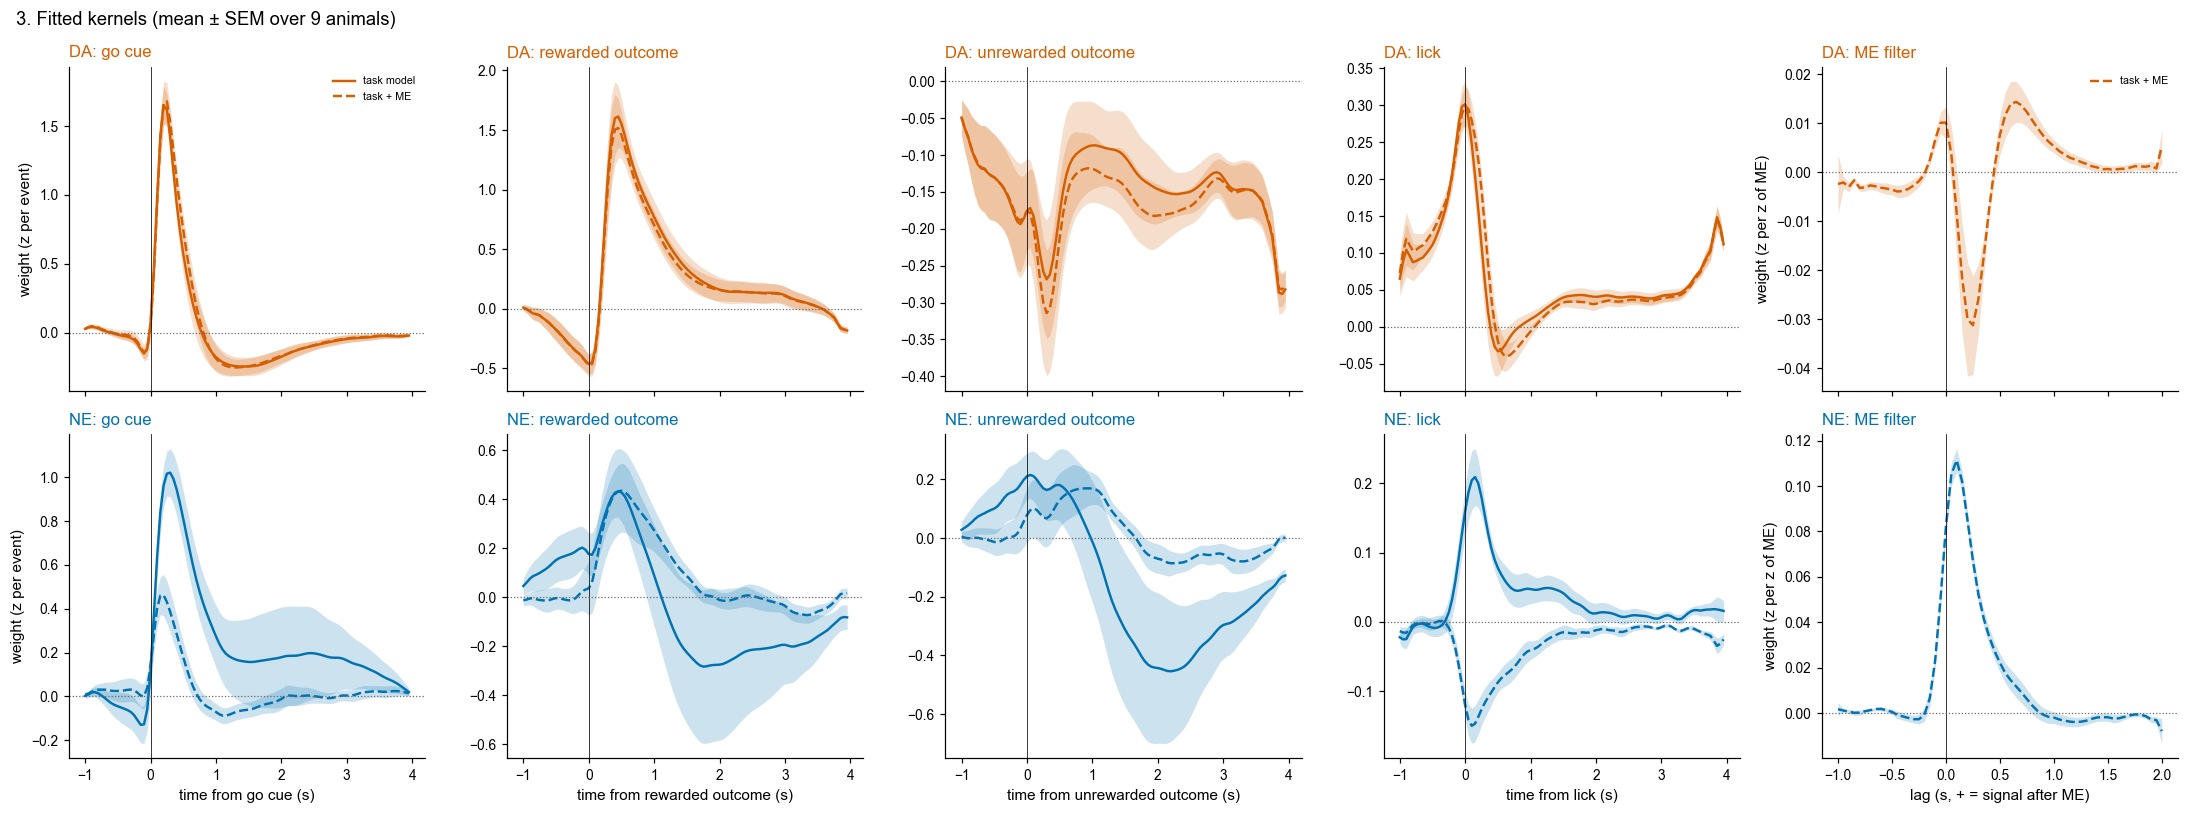

In [8]:
fits = pd.DataFrame(model_fits)
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharex="col")
for r, sig in enumerate(("da", "ne")):
    for c, name in enumerate(EVENTS + ["ME"]):
        ax = axes[r, c]
        for model, ls in (("task", "-"), ("both", "--")):
            ks = [split_beta(b) for b in fits[f"{sig}_{model}_beta"]]
            if name not in ks[0]:
                continue
            x = ME_T if name == "ME" else KERNEL_T
            curves = st.group_means([k[name] for k in ks], fits["subject"])[1]
            pu.plot_mean_sem(ax, x, curves, SIG_COLOR[sig],
                             "task + ME" if model == "both" else "task model", ls=ls)
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_title(f"{sig.upper()}: {name if name != 'ME' else 'ME filter'}", loc="left",
                     color=SIG_COLOR[sig])
        if r == 1:
            ax.set_xlabel("lag (s, + = signal after ME)" if name == "ME" else f"time from {name} (s)")
        if c == 0:
            ax.set_ylabel("weight (z per event)")
        if c == 4:
            ax.set_ylabel("weight (z per z of ME)")
        if r == 0 and c in (0, 4):
            ax.legend(fontsize=7)
        style_ax(ax)
fig.suptitle(f"3. Fitted kernels (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "fip_13_3_kernels", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. The DA–NE correlation with task and movement removed

Zero-lag Pearson r of DA and NE per session: raw (z-scored), after removing what lagged ME
explains, after removing the task model, and after removing task + ME (the residuals of the fits in
section 1).

── DA–NE zero-lag r
           measure   mean    sem       p  n
               raw  0.255 0.0389 0.00391  9
          minus_me 0.0623 0.0192  0.0195  9
        minus_task 0.0189 0.0305   0.496  9
     minus_task_me 0.0647 0.0208  0.0273  9
task_me_minus_task 0.0458 0.0142  0.0273  9
      me_minus_raw -0.193 0.0273 0.00391  9



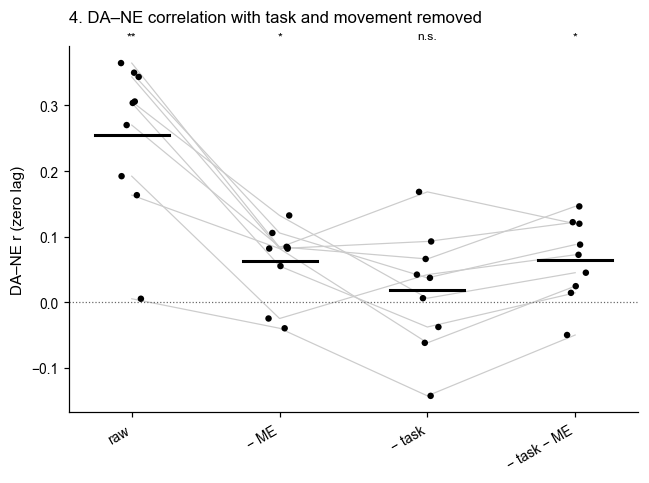

In [9]:
rows = []
for p in pairs:
    f = resid[p["session"]]
    rows.append(dict(
        subject=p["subject"], session=p["session"],
        raw=np.corrcoef(p["z"]["da"], p["z"]["ne"])[0, 1],
        minus_me=np.corrcoef(f["me_only"]["da_res"], f["me_only"]["ne_res"])[0, 1],
        minus_task=np.corrcoef(f["task"]["da_res"], f["task"]["ne_res"])[0, 1],
        minus_task_me=np.corrcoef(f["both"]["da_res"], f["both"]["ne_res"])[0, 1]))
coup_sess = pd.DataFrame(rows)
coup_animal = st.animal_means(coup_sess, ["raw", "minus_me", "minus_task", "minus_task_me"],
                              by_session=False)
coup_animal["task_me_minus_task"] = coup_animal["minus_task_me"] - coup_animal["minus_task"]
coup_animal["me_minus_raw"] = coup_animal["minus_me"] - coup_animal["raw"]
report("DA–NE zero-lag r", coup_animal, list(coup_animal))

fig, ax = plt.subplots(figsize=(6, 4.5))
pu.strip_by_measure(ax, coup_animal, ["raw", "minus_me", "minus_task", "minus_task_me"],
                    ["raw", "− ME", "− task", "− task − ME"], ["k"] * 4, "DA–NE r (zero lag)",
                    title="4. DA–NE correlation with task and movement removed")
fig.tight_layout()
save_fig(fig, "fip_13_4_coupling", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. The DA–NE correlation by timescale

Zero-lag DA–NE correlation of the raw (z-scored) traces and of the task-model residuals (section 1's
task fit, no ME), after band-pass filtering into five bands (`su.band_corr_with_null`), against NE
circularly shifted by at least 120 s. Then the cross-correlation of the raw traces and of the task
residuals, and one session's slow components.

In [10]:
band_rows = []
for p in pairs:
    r = resid[p["session"]]["task"]
    r_raw, n_raw = su.band_corr_with_null(r["da"], r["ne"], FS, BANDS, MIN_SHIFT_BAND_S, N_NULL, rng)
    r_res, n_res = su.band_corr_with_null(r["da_res"], r["ne_res"], FS, BANDS, MIN_SHIFT_BAND_S, N_NULL, rng)
    band_rows.append(dict(subject=p["subject"], session=p["session"], r_raw=r_raw, null_raw=n_raw,
                          r_res=r_res, null_res=n_res,
                          r_all_raw=np.corrcoef(r["da"], r["ne"])[0, 1],
                          r_all_res=np.corrcoef(r["da_res"], r["ne_res"])[0, 1],
                          r_all_fit=np.corrcoef(r["da_fit"], r["ne_fit"])[0, 1],
                          r2_da=r["da_r2"], r2_ne=r["ne_r2"]))
band_df = pd.DataFrame(band_rows)

band_raw, band_res = (st.group_means(band_df[c], band_df["subject"])[1] for c in ("r_raw", "r_res"))
null_raw, null_res = (st.group_means(band_df[c], band_df["subject"])[1]  # (animal, band, shift)
                      for c in ("null_raw", "null_res"))
# Null of the grand mean: shift draw k averaged over sessions, animals.
gm_null_raw, gm_null_res = null_raw.mean(0), null_res.mean(0)

tbl = pd.DataFrame({"raw r": band_raw.mean(0), "residual r": band_res.mean(0),
                    "null 2.5–97.5% (raw)": [f"{np.percentile(x, 2.5):+.3f} … {np.percentile(x, 97.5):+.3f}" for x in gm_null_raw],
                    "p raw (Wilcoxon)": [st.wilcoxon_animals(band_raw[:, k])[1] for k in range(len(BANDS))],
                    "p residual (Wilcoxon)": [st.wilcoxon_animals(band_res[:, k])[1] for k in range(len(BANDS))]},
                   index=BAND_NAMES)
whole = st.animal_means(band_df, ["r_all_raw", "r_all_res", "r_all_fit", "r2_da", "r2_ne"], by_session=False)
print("whole-signal r, mean over animals:", whole.mean().round(3).to_dict())
tbl.round(3)

# cross-correlation of the raw traces and of the task residuals
xc_rows = []
for p in pairs:
    r = resid[p["session"]]["task"]
    xl, xc_res = su.norm_xcorr(r["ne_res"], r["da_res"], FS, maxlag=MAXLAG_S)  # + lag = NE later
    xl, xc_raw = su.norm_xcorr(r["ne"], r["da"], FS, maxlag=MAXLAG_S)
    xc_rows.append(dict(subject=p["subject"], xc_res=xc_res, xc_raw=xc_raw))
xc_df = pd.DataFrame(xc_rows)
_, xc_res_animal = st.group_means(xc_df["xc_res"], xc_df["subject"])
_, xc_raw_animal = st.group_means(xc_df["xc_raw"], xc_df["subject"])
print("residual xcorr peak lag per animal (s, + = NE later):",
      pd.Series(xl[np.argmax(np.abs(xc_res_animal), 1)], index=SUBJECTS).round(2).to_dict())

whole-signal r, mean over animals: {'r_all_raw': 0.255, 'r_all_res': 0.019, 'r_all_fit': 0.716, 'r2_da': 0.453, 'r2_ne': 0.254}


residual xcorr peak lag per animal (s, + = NE later): {'800886': -0.45, '808054': -0.5, '809487': -0.5, '809491': 0.05, '815334': 0.0, '816212': -0.1, '816214': 0.2, '818585': -0.1, '818586': -0.25}


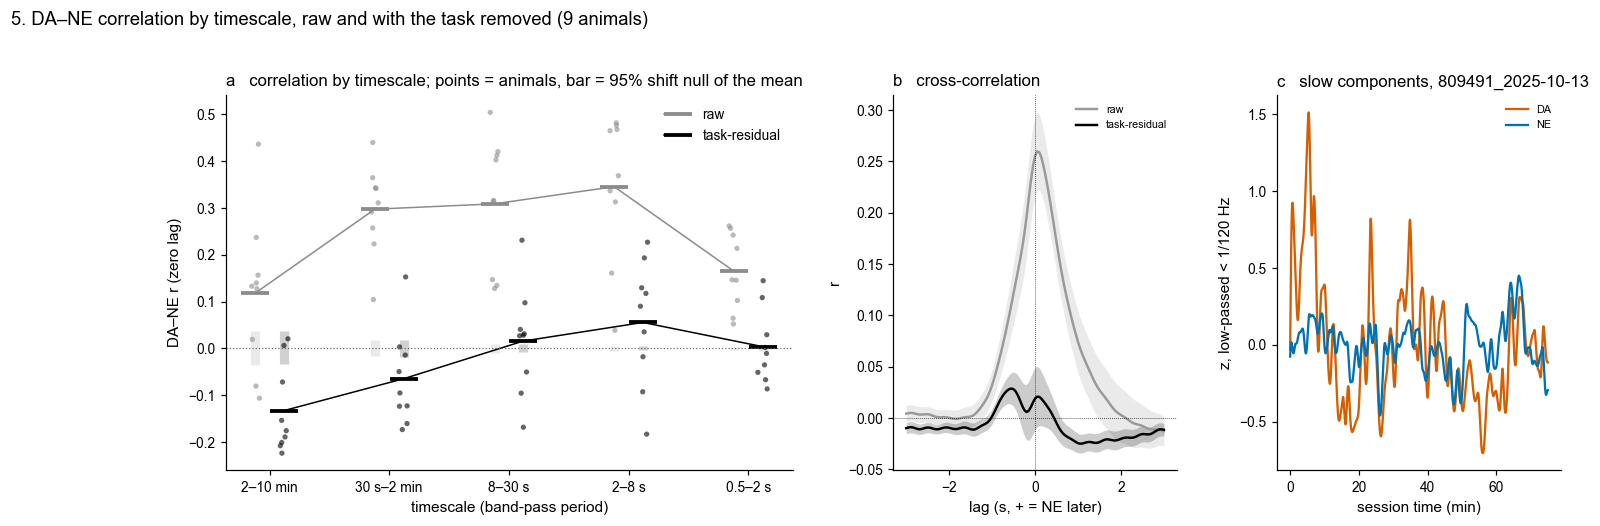

In [11]:
from scipy import signal as sps

fig = plt.figure(figsize=(17, 4.8))
gs = GridSpec(1, 4, figure=fig, wspace=0.35, top=0.82, width_ratios=[2, 1, 1, 0.05])
ax = fig.add_subplot(gs[0])
x = np.arange(len(BANDS))
for arr, nul, col, lab, dx in ((band_raw, gm_null_raw, "0.55", "raw", -0.12),
                               (band_res, gm_null_res, "k", "task-residual", 0.12)):
    for k in range(len(BANDS)):
        ax.scatter(np.full(len(arr), x[k] + dx) + (rng.random(len(arr)) - 0.5) * 0.08, arr[:, k],
                   s=12, color=col, alpha=0.6, edgecolor="none")
        lo, hi = np.percentile(nul[k], [2.5, 97.5])
        ax.plot([x[k] + dx] * 2, [lo, hi], color=col, lw=6, alpha=0.18, solid_capstyle="butt")
    ax.plot(x + dx, arr.mean(0), color=col, marker="_", ms=18, mew=2.5, ls="-", lw=1, label=lab)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_xticks(x)
ax.set_xticklabels(BAND_NAMES)
ax.set_xlabel("timescale (band-pass period)")
ax.set_ylabel("DA–NE r (zero lag)")
ax.set_title("a   correlation by timescale; points = animals, bar = 95% shift null of the mean",
             loc="left")
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[1])
for arr, col, lab in ((xc_raw_animal, "0.6", "raw"), (xc_res_animal, "k", "task-residual")):
    pu.plot_mean_sem(ax, xl, arr, col, lab)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title("b   cross-correlation", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[2])
sos = sps.butter(2, 1 / 120, btype="low", fs=FS, output="sos")
t_min = (ex["t0"] + np.arange(len(ex["da"])) / FS) / 60
for sig in ("da", "ne"):
    ax.plot(t_min, sps.sosfiltfilt(sos, ex["z"][sig]), color=SIG_COLOR[sig], label=sig.upper())
ax.set_xlabel("session time (min)")
ax.set_ylabel("z, low-passed < 1/120 Hz")
ax.set_title(f"c   slow components, {ex['session']}", loc="left")
ax.legend(fontsize=7)
style_ax(ax)
fig.suptitle(f"5. DA–NE correlation by timescale, raw and with the task removed ({N_ANIMALS} animals)",
             x=0.01, ha="left")
save_fig(fig, "fip_13_5_timescales", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Numbers

One row per measure: mean over animals, Wilcoxon p against zero, animals positive.

In [12]:
def row(section, measure, df, col):
    # one measure of an animal table: mean, Wilcoxon p against 0, animals positive
    v = df[col]
    m, p, n = st.wilcoxon_animals(v)
    return dict(section=section, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


S = [row("1", f"{s.upper()} R², {lab}", r2_animal, f"{s}_{c}")
     for s in ("da", "ne") for c, lab in (("task", "task"), ("me", "ME alone"), ("task_me", "task + ME"))]
S += [row("1", f"{s.upper()} ΔR² from ME minus shifted-ME null", r2_animal, f"{s}_me_added_vs_null")
      for s in ("da", "ne")]
S += [row("4", f"DA–NE r, {c}", coup_animal, c) for c in ("raw", "minus_me", "minus_task", "minus_task_me")]
S += [row("4", "DA–NE r: (− task − ME) minus (− task)", coup_animal, "task_me_minus_task")]
bands = pd.DataFrame(np.c_[band_raw, band_res], columns=[f"raw, {b}" for b in BAND_NAMES]
                     + [f"task-residual, {b}" for b in BAND_NAMES])
S += [row("5", f"DA–NE r, {c}", bands, c) for c in bands]
pd.DataFrame(S).set_index(["section", "measure"])

mean       p animals_positive
section measure                                                              
1       DA R², task                            0.453  0.0039              9/9
        DA R², ME alone                        0.162  0.0039              9/9
        DA R², task + ME                       0.472  0.0039              9/9
        NE R², task                            0.254  0.0039              9/9
        NE R², ME alone                        0.491  0.0039              9/9
        NE R², task + ME                       0.535  0.0039              9/9
        DA ΔR² from ME minus shifted-ME null   0.018  0.0039              9/9
        NE ΔR² from ME minus shifted-ME null   0.280  0.0039              9/9
4       DA–NE r, raw                           0.255  0.0039              9/9
        DA–NE r, minus_me                      0.062  0.0195              7/9
        DA–NE r, minus_task                    0.019  0.4961              6/9
        DA–NE r, minus_task_me                 0.065  0.0273              8/9
        DA–NE r: (− task − ME) minus (− task)  0.046  0.0273              8/9
5       DA–NE r, raw, 2–10 min                 0.118  0.0391              7/9
        DA–NE r, raw, 30 s–2 min               0.297  0.0039              9/9
        DA–NE r, raw, 8–30 s                   0.309  0.0039              9/9
        DA–NE r, raw, 2–8 s                    0.345  0.0039              9/9
        DA–NE r, raw, 0.5–2 s                  0.165  0.0039              9/9
        DA–NE r, task-residual, 2–10 min      -0.133  0.0195              2/9
        DA–NE r, task-residual, 30 s–2 min    -0.065  0.0977              2/9
        DA–NE r, task-residual, 8–30 s         0.016  0.7344              6/9
        DA–NE r, task-residual, 2–8 s          0.055  0.2500              6/9
        DA–NE r, task-residual, 0.5–2 s        0.004  0.9102              4/9